# Interpretable Heart Disease Classification

### A Comparative Study of Six Machine Learning Classifiers Using SMOTETomek and SHAP

**Author:** Kausturi Chakraborty  
**Department of Computer Science and Engineering, Adamas University, Kolkata, India**

---

## Research Objective

This project investigates the performance of multiple machine learning classifiers for heart disease classification using the 2023 Behavioral Risk Factor Surveillance System (BRFSS) dataset.

The study focuses on three key aspects:

1. **Comparative model evaluation** across multiple machine learning classifiers.
2. **Class imbalance handling** using SMOTETomek on the training data.
3. **Model interpretability** using SHAP (SHapley Additive exPlanations).

Because the dataset contains substantial class imbalance, model performance is evaluated using multiple metrics rather than relying on accuracy alone. These include accuracy, precision, recall, F1-score, ROC-AUC, and PR-AUC.

Stratified cross-validation is also used to assess model performance, while SHAP is used to investigate influential features contributing to model predictions.

In [ ]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Imbalanced learning
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline

# XGBoost
from xgboost import XGBClassifier

# Explainability
import shap

# Reproducibility
RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Dataset

The analysis uses the 2023 Behavioral Risk Factor Surveillance System (BRFSS) dataset.

The raw dataset contains 433,323 records and 350 variables. The target variable used in this study is `_MICHD`, which represents whether a respondent has ever reported coronary heart disease (CHD) or myocardial infarction (MI).

The raw BRFSS dataset is not included in this repository. The dataset should be obtained separately and its local path specified before running the analysis.

In [ ]:
# Path to the BRFSS 2023 dataset.
# Update this path to the location of LLCP2023.XPT on your machine.
DATA_PATH = "path to dataset"


# Target variable
TARGET_COL = "_MICHD"

# Load dataset
df = pd.read_sas(DATA_PATH)

print("Raw shape:", df.shape)
print("Target present:", TARGET_COL in df.columns)
print("\nTarget distribution before cleaning:")
print(df[TARGET_COL].value_counts(dropna=False))

Raw shape: (433323, 350)
Target present: True

Target distribution before cleaning:
_MICHD
2.0    392427
1.0     36311
NaN      4585
Name: count, dtype: int64


## 2. Target Cleaning

The target variable `_MICHD` contains the original BRFSS coding:

- `1` → Heart disease / myocardial infarction reported
- `2` → No heart disease / myocardial infarction reported

Records with a missing target value are removed, and the remaining target values are mapped to binary labels:

- `1` → Positive class
- `0` → Negative class

In [ ]:
# Remove observations with a missing target
df = df[df[TARGET_COL].notna()].copy()

# Convert the original BRFSS target coding to binary labels
df[TARGET_COL] = df[TARGET_COL].map({
    1.0: 1,
    2.0: 0
})

print("After dropping missing target:", df.shape)
print("\nTarget distribution:")
print(df[TARGET_COL].value_counts())

After dropping missing target: (428738, 350)

Target distribution:
_MICHD
0    392427
1     36311
Name: count, dtype: int64


## 3. Data Cleaning

The dataset is checked for duplicate observations and duplicate columns.

Duplicate rows are removed first. Duplicate columns are then identified by comparing their values and removed when present.

In [ ]:
print("Before duplicate removal:", df.shape)

# Remove duplicate rows
n_before = len(df)

df = df.drop_duplicates().reset_index(drop=True)

n_after = len(df)

print(f"Duplicate rows removed: {n_before - n_after}")

# Identify duplicate columns
dup_cols = []
cols = df.columns.tolist()

for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        if df[cols[i]].equals(df[cols[j]]):
            dup_cols.append(cols[j])

dup_cols = list(set(dup_cols))

# Remove duplicate columns
if dup_cols:
    print(f"Duplicate columns found and removed: {dup_cols}")
    df = df.drop(columns=dup_cols)
else:
    print("No duplicate columns found.")

print("After duplicate removal:", df.shape)

Before duplicate removal: (428738, 350)
Duplicate rows removed: 0
Duplicate columns found and removed: ['NUMBURN3', 'SUNPRTCT', 'WKDAYOUT', 'CTELNUM1', 'CELLFON5', 'WKENDOUT', 'CADULT1']
After duplicate removal: (428738, 343)


## 4. Dataset Sampling

Following data cleaning, 80,000 observations are sampled using a fixed random seed of 42.

The fixed seed ensures that the analysis remains reproducible.

In [ ]:
# Sample up to 80,000 observations
df = df.sample(
    n=min(80000, len(df)),
    random_state=RANDOM_STATE
).reset_index(drop=True)

print("Sampled dataset shape:", df.shape)

print("\nTarget distribution:")
print(df[TARGET_COL].value_counts())

print("\nTarget proportion:")
print(df[TARGET_COL].value_counts(normalize=True).round(4))

Sampled dataset shape: (80000, 343)

Target distribution:
_MICHD
0    73280
1     6720
Name: count, dtype: int64

Target proportion:
_MICHD
0    0.916
1    0.084
Name: proportion, dtype: float64


## 5. Feature Selection

Twenty-six predictor variables are selected from the BRFSS dataset based on their relevance to the classification task.

The target variable `_MICHD` is retained separately as the prediction target.

In [ ]:
keep_cols = [
    "_MICHD",
    "GENHLTH", "PHYSHLTH", "MENTHLTH",
    "BPHIGH6", "TOLDHI3", "CVDSTRK3",
    "DIABETE4", "CHCCOPD3", "ADDEPEV3",
    "CHCKDNY2", "HAVARTH4", "ASTHMA3",
    "SMOKE100", "ALCDAY4", "AVEDRNK3",
    "EXERANY2", "STRENGTH",
    "_BMI5", "_AGE_G", "SEXVAR",
    "EDUCA", "INCOME3", "EMPLOY1",
    "DIFFDRES", "DIFFWALK", "DECIDE"
]

# Retain only columns available in the dataset
keep_cols = [c for c in keep_cols if c in df.columns]

df = df[keep_cols].copy()

print(f"Using {len(keep_cols) - 1} predictors")
print("Dataset shape:", df.shape)

print("\nTop 10 columns by missing values:")
print(df.isna().sum().sort_values(ascending=False).head(10))

Using 26 predictors
Dataset shape: (80000, 27)

Top 10 columns by missing values:
AVEDRNK3    40653
TOLDHI3      9507
_BMI5        7284
ALCDAY4      4689
SMOKE100     3637
DIFFDRES     3119
DIFFWALK     2994
DECIDE       2804
INCOME3      1504
EMPLOY1       554
dtype: int64


## 6. Train-Test Split

The data is divided into training and held-out test sets using an 80:20 stratified split.

Stratification preserves the target-class proportions across the two partitions.

The test set is kept separate from model training, resampling, and model selection and is used for final evaluation.

In [ ]:
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

print("X:", X.shape)
print("y:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("\nAfter train/test split:")
print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("y_train:", y_train.shape, " y_test:", y_test.shape)

X: (80000, 26)
y: (80000,)

After train/test split:
X_train: (64000, 26)  X_test: (16000, 26)
y_train: (64000,)  y_test: (16000,)


## 7. Preprocessing

Missing values are imputed using the most-frequent strategy.

Standardization is then applied using `StandardScaler`.

The imputer and scaler are fitted using the training data only and subsequently applied to the held-out test data.

In [ ]:
# Missing-value imputation
imputer = SimpleImputer(strategy="most_frequent")

X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)

# Feature standardization
scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train_imp)
X_test_s = scaler.transform(X_test_imp)

print("After preprocessing:")
print("X_train_s:", X_train_s.shape)
print("X_test_s:", X_test_s.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTest class distribution:")
print(y_test.value_counts())

After preprocessing:
X_train_s: (64000, 26)
X_test_s: (16000, 26)

Training class distribution:
_MICHD
0    58624
1     5376
Name: count, dtype: int64

Test class distribution:
_MICHD
0    14656
1     1344
Name: count, dtype: int64


## 8. Class Imbalance Handling

The training data contains substantially fewer positive-class observations than negative-class observations.

SMOTETomek is applied to the training data to address this imbalance.

SMOTETomek combines:

- **SMOTE**, which generates synthetic minority-class observations.
- **Tomek links**, which remove selected overlapping observations between classes.

Importantly, resampling is performed only on the training data. The held-out test set remains in its original class distribution.

In [ ]:
smote_tomek = SMOTETomek(random_state=RANDOM_STATE)

X_train_res, y_train_res = smote_tomek.fit_resample(
    X_train_s,
    y_train
)

print(
    "Before resampling:",
    X_train_s.shape,
    y_train.value_counts().to_dict()
)

print(
    "After resampling:",
    X_train_res.shape,
    pd.Series(y_train_res).value_counts().to_dict()
)

Before resampling: (64000, 26) {0: 58624, 1: 5376}
After resampling: (117128, 26) {0: 58564, 1: 58564}


## 9. Model Training and Evaluation

Five machine learning classifiers are evaluated alongside a majority-class baseline:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. Support Vector Machine (SVM) with an RBF kernel
5. XGBoost

The non-baseline models are trained using the SMOTETomek-resampled training data and evaluated on the untouched, imbalanced test set.

Accuracy, F1-score, and ROC-AUC are recorded for comparative evaluation.

In [ ]:
results = []

def evaluate_model(name, y_true, y_pred, y_prob=None):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob) if y_prob is not None else None

    print(f"\n--- {name} ---")
    print(f"Accuracy : {acc:.4f}")
    print(f"F1 (pos) : {f1:.4f}")

    if auc is not None:
        print(f"ROC-AUC  : {auc:.4f}")

    print(classification_report(y_true, y_pred, digits=4))

    results.append({
        "Model": name,
        "Accuracy": round(acc * 100, 2),
        "F1 (class 1)": round(f1, 3),
        "ROC-AUC": round(auc, 4) if auc is not None else np.nan
    })

In [ ]:
# Majority-class baseline

dummy = DummyClassifier(
    strategy="most_frequent",
    random_state=RANDOM_STATE
)

dummy.fit(X_train_s, y_train)

y_pred = dummy.predict(X_test_s)

evaluate_model(
    "Baseline (majority class)",
    y_test,
    y_pred
)


--- Baseline (majority class) ---
Accuracy : 0.9160
F1 (pos) : 0.0000
              precision    recall  f1-score   support

           0     0.9160    1.0000    0.9562     14656
           1     0.0000    0.0000    0.0000      1344

    accuracy                         0.9160     16000
   macro avg     0.4580    0.5000    0.4781     16000
weighted avg     0.8391    0.9160    0.8758     16000



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Logistic Regression

log_reg = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

log_reg.fit(X_train_res, y_train_res)

y_pred = log_reg.predict(X_test_s)
y_prob = log_reg.predict_proba(X_test_s)[:, 1]

evaluate_model(
    "Logistic Regression",
    y_test,
    y_pred,
    y_prob
)


--- Logistic Regression ---
Accuracy : 0.7405
F1 (pos) : 0.3355
ROC-AUC  : 0.8348
              precision    recall  f1-score   support

           0     0.9733    0.7369    0.8388     14656
           1     0.2137    0.7798    0.3355      1344

    accuracy                         0.7405     16000
   macro avg     0.5935    0.7583    0.5871     16000
weighted avg     0.9095    0.7405    0.7965     16000



In [ ]:
# Decision Tree

dt = DecisionTreeClassifier(
    max_depth=6,
    random_state=RANDOM_STATE
)

dt.fit(X_train_res, y_train_res)

y_pred = dt.predict(X_test_s)
y_prob = dt.predict_proba(X_test_s)[:, 1]

evaluate_model(
    "Decision Tree",
    y_test,
    y_pred,
    y_prob
)


--- Decision Tree ---
Accuracy : 0.8155
F1 (pos) : 0.3466
ROC-AUC  : 0.8031
              precision    recall  f1-score   support

           0     0.9563    0.8369    0.8926     14656
           1     0.2467    0.5826    0.3466      1344

    accuracy                         0.8155     16000
   macro avg     0.6015    0.7097    0.6196     16000
weighted avg     0.8967    0.8155    0.8467     16000



In [ ]:
# Random Forest

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf.fit(X_train_res, y_train_res)

y_pred = rf.predict(X_test_s)
y_prob = rf.predict_proba(X_test_s)[:, 1]

evaluate_model(
    "Random Forest",
    y_test,
    y_pred,
    y_prob
)


--- Random Forest ---
Accuracy : 0.8367
F1 (pos) : 0.3751
ROC-AUC  : 0.8389
              precision    recall  f1-score   support

           0     0.9575    0.8600    0.9061     14656
           1     0.2764    0.5833    0.3751      1344

    accuracy                         0.8367     16000
   macro avg     0.6170    0.7217    0.6406     16000
weighted avg     0.9003    0.8367    0.8615     16000



In [ ]:
# Support Vector Machine
# A maximum of 20,000 resampled training observations is used.

svm_n = min(20000, len(X_train_res))

rng = np.random.RandomState(RANDOM_STATE)

svm_indices = rng.choice(
    len(X_train_res),
    size=svm_n,
    replace=False
)

X_svm = X_train_res[svm_indices]
y_svm = np.asarray(y_train_res)[svm_indices]

print(f"SVM training size: {X_svm.shape}")

svm = SVC(
    kernel="rbf",
    probability=True,
    random_state=RANDOM_STATE
)

svm.fit(X_svm, y_svm)

y_pred = svm.predict(X_test_s)
y_prob = svm.predict_proba(X_test_s)[:, 1]

evaluate_model(
    "SVM",
    y_test,
    y_pred,
    y_prob
)

SVM training size: (20000, 26)

--- SVM ---
Accuracy : 0.7776
F1 (pos) : 0.3452
ROC-AUC  : 0.8204
              precision    recall  f1-score   support

           0     0.9659    0.7849    0.8660     14656
           1     0.2293    0.6979    0.3452      1344

    accuracy                         0.7776     16000
   macro avg     0.5976    0.7414    0.6056     16000
weighted avg     0.9040    0.7776    0.8223     16000



In [ ]:
# XGBoost
model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    tree_method="hist",
    random_state=RANDOM_STATE,
    eval_metric="logloss",
    n_jobs=-1
)

model.fit(X_train_res, y_train_res)

y_pred_xgb = model.predict(X_test_s)
y_prob_xgb = model.predict_proba(X_test_s)[:, 1]

evaluate_model(
    "XGBoost",
    y_test,
    y_pred_xgb,
    y_prob_xgb
)


--- XGBoost ---
Accuracy : 0.9151
F1 (pos) : 0.1945
ROC-AUC  : 0.8445
              precision    recall  f1-score   support

           0     0.9246    0.9879    0.9552     14656
           1     0.4795    0.1220    0.1945      1344

    accuracy                         0.9151     16000
   macro avg     0.7021    0.5549    0.5749     16000
weighted avg     0.8873    0.9151    0.8913     16000



## 10. Model Comparison

The performance of the evaluated classifiers is summarized using test-set accuracy, positive-class F1-score, and ROC-AUC.

In [ ]:
results_df = pd.DataFrame(results)

print("=== FINAL MODEL COMPARISON ===")
print(results_df.to_string(index=False))

=== FINAL MODEL COMPARISON ===
                    Model  Accuracy  F1 (class 1)  ROC-AUC
Baseline (majority class)     91.60         0.000      NaN
      Logistic Regression     74.05         0.335   0.8348
            Decision Tree     81.55         0.347   0.8031
            Random Forest     83.67         0.375   0.8389
                      SVM     77.76         0.345   0.8204
                  XGBoost     91.51         0.195   0.8445


## 11. Detailed XGBoost Evaluation

XGBoost is further evaluated using:

- Accuracy
- F1-score
- ROC-AUC
- PR-AUC
- Classification report
- Confusion matrix

PR-AUC is included because it provides additional information about performance on the positive class in an imbalanced classification setting.

Test set size: 16000
Accuracy : 0.9151
F1 Score : 0.1945
ROC-AUC  : 0.8445
PR-AUC   : 0.3330

Classification Report:
              precision    recall  f1-score   support

           0     0.9246    0.9879    0.9552     14656
           1     0.4795    0.1220    0.1945      1344

    accuracy                         0.9151     16000
   macro avg     0.7021    0.5549    0.5749     16000
weighted avg     0.8873    0.9151    0.8913     16000



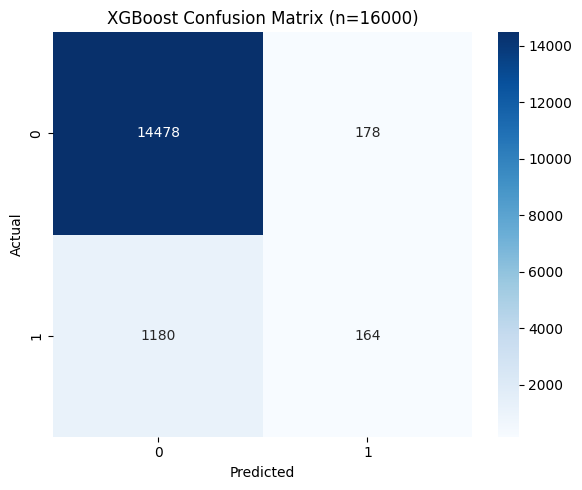

In [ ]:
y_pred = model.predict(X_test_s)
y_prob = model.predict_proba(X_test_s)[:, 1]

print("Test set size:", X_test_s.shape[0])

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

print(f"Accuracy : {accuracy:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
print(f"PR-AUC   : {pr_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(f"XGBoost Confusion Matrix (n={X_test_s.shape[0]})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## 12. Five-Fold Stratified Cross-Validation

Five-fold stratified cross-validation is performed on the training partition for Logistic Regression, Decision Tree, Random Forest, and XGBoost.

SMOTETomek is applied within each cross-validation fold.

The held-out test set is not used during cross-validation.

The cross-validation results are used to assess the consistency of model performance across different training folds.

In [ ]:
cv_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=6,
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.1,
        tree_method="hist",
        random_state=RANDOM_STATE,
        eval_metric="logloss",
        n_jobs=-1
    )
}

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_results = []

for name, clf in cv_models.items():

    pipe = ImbPipeline(
        steps=[
            ("smote", SMOTETomek(random_state=RANDOM_STATE)),
            ("clf", clf)
        ]
    )

    scores = cross_validate(
        pipe,
        X_train_s,
        y_train,
        cv=skf,
        scoring=[
            "accuracy",
            "f1",
            "roc_auc"
        ],
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "CV Accuracy (mean)": round(
            scores["test_accuracy"].mean() * 100, 2
        ),
        "CV Accuracy (std)": round(
            scores["test_accuracy"].std() * 100, 2
        ),
        "CV F1 (mean)": round(
            scores["test_f1"].mean(), 3
        ),
        "CV ROC-AUC (mean)": round(
            scores["test_roc_auc"].mean(), 4
        )
    })

    print(f"{name}: done")

cv_results_df = pd.DataFrame(cv_results)

print("\n=== 5-FOLD CROSS-VALIDATION RESULTS ===")
print(cv_results_df.to_string(index=False))

Logistic Regression: done
Decision Tree: done
Random Forest: done
XGBoost: done

=== 5-FOLD CROSS-VALIDATION RESULTS ===
              Model  CV Accuracy (mean)  CV Accuracy (std)  CV F1 (mean)  CV ROC-AUC (mean)
Logistic Regression               73.32               0.47         0.330             0.8298
      Decision Tree               81.68               1.30         0.340             0.8016
      Random Forest               83.11               0.13         0.363             0.8309
            XGBoost               91.59               0.15         0.211             0.8371


## 13. Model Explainability with SHAP

SHAP (SHapley Additive exPlanations) is used to examine the contribution of individual features to XGBoost predictions.

A subset of 1,000 observations from the held-out test set is used for the SHAP visualization.

The resulting summary plot provides a global view of the features that most strongly influence the model's predictions.

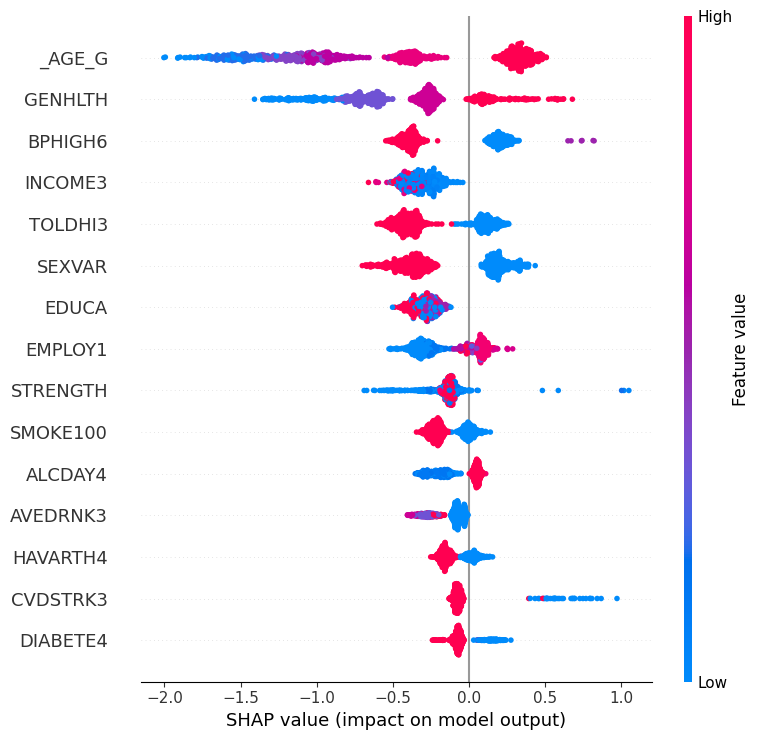

In [ ]:
# Feature names
feature_names = X.columns.tolist()

# Create SHAP explainer for the trained XGBoost model
explainer = shap.TreeExplainer(model)

# Use a subset of the held-out test data
X_shap = pd.DataFrame(
    X_test_s[:1000],
    columns=feature_names
)

# Calculate SHAP values
shap_values = explainer.shap_values(X_shap)

# SHAP summary plot
shap.summary_plot(
    shap_values,
    X_shap,
    max_display=15
)

## 14. Conclusions

The experiments demonstrate that model performance can differ substantially depending on the evaluation metric used in an imbalanced classification problem.

XGBoost achieved the highest test accuracy and ROC-AUC among the evaluated classifiers, while Random Forest achieved the highest positive-class F1-score.

The SHAP analysis identified several influential predictors, including age group, general health, high blood pressure, income, high cholesterol, and sex.

These results highlight the importance of evaluating multiple performance metrics and incorporating model interpretability when applying machine learning to health-related classification tasks.

## Reproducibility Notes

- Random seed: `42`
- Train-test split: `80:20`
- Sampling size: `80,000` observations
- Class imbalance handling: `SMOTETomek`
- Cross-validation: `5-fold StratifiedKFold`
- Explainability method: `SHAP`
- The original BRFSS dataset is not distributed with this repository.
- The accompanying research paper provides the detailed methodology, experimental results, and discussion.